In [1]:
import pandas as pd
import matplotlib.pyplot as plt

โหลดข้อมูล

In [2]:
df = pd.read_csv('protein_capped.csv')

ดูข้อมูลเบื้องต้น

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44019 entries, 0 to 44018
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    44019 non-null  float64
 1   F1      44019 non-null  float64
 2   F2      44019 non-null  float64
 3   F3      44019 non-null  float64
 4   F4      44019 non-null  float64
 5   F5      44019 non-null  float64
 6   F6      44019 non-null  float64
 7   F7      44019 non-null  float64
 8   F8      44019 non-null  float64
 9   F9      44019 non-null  float64
dtypes: float64(10)
memory usage: 3.4 MB
None


ดูข้อมูล5แถวแรก

In [4]:
print(df.head())

     RMSD        F1       F2       F3        F4            F5        F6  \
0  17.284  13558.30  4305.35  0.31754  162.1730  1.872791e+06  215.3590   
1   6.021   6191.96  1623.16  0.26213   53.3894  8.034467e+05   87.2024   
2   9.275   7725.98  1726.28  0.22343   67.2887  1.075648e+06   81.7913   
3  15.851   8424.58  2368.25  0.28111   67.8325  1.210472e+06  109.4390   
4   7.962   7460.84  1736.94  0.23280   52.4123  1.021020e+06   94.5234   

        F7     F8       F9  
0  4287.87  102.0  27.0302  
1  3328.91   39.0  38.5468  
2  2981.04   29.0  38.8119  
3  3248.22   70.0  39.0651  
4  2814.42   41.0  39.9147  


ตรวจสอบค่าว่าง (Missing Values)

In [5]:
print(df.isnull().sum())

RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      0
F9      0
dtype: int64


ตรวจสอบค่าซ้ำ

In [8]:
duplicate_count = df.duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันทั้งหมด: {duplicate_count} แถว")

# แสดงแถวที่ซ้ำกัน
if duplicate_count > 0:
    duplicates = df[df.duplicated(keep=False)]
    print(duplicates.sort_values(by=list(df.columns)).head(10))

จำนวนแถวที่ซ้ำกันทั้งหมด: 11 แถว
        RMSD          F1        F2       F3          F4            F5  \
36726  2.582  19900.0675  6243.890  0.27883  238.624575  2.795880e+06   
38569  2.582  19900.0675  6243.890  0.27883  238.624575  2.795880e+06   
4999   3.191  19900.0675  6504.665  0.29736  238.624575  2.795880e+06   
9284   3.191  19900.0675  6504.665  0.29736  238.624575  2.795880e+06   
22502  3.191  19900.0675  6504.665  0.29736  238.624575  2.795880e+06   
42413  3.191  19900.0675  6504.665  0.29736  238.624575  2.795880e+06   
8654   3.223  19900.0675  6445.050  0.28368  238.624575  2.795880e+06   
13298  3.223  19900.0675  6445.050  0.28368  238.624575  2.795880e+06   
28734  3.345  19900.0675  6504.665  0.30017  238.624575  2.795880e+06   
42755  3.345  19900.0675  6504.665  0.30017  238.624575  2.795880e+06   

             F6       F7    F8       F9  
36726  311.4479  6431.85  92.0  17.7713  
38569  311.4479  6431.85  92.0  17.7713  
4999   311.4479  6304.89  91.0  17.77

ทำการลบค่าซ้ำเนื่องจากยังเหลืออยู่11แถว ถือว่าเป็นความผิดพลาดของผู้จัดทำที่จัดการไม่หมด

In [9]:
df_cleaned = df.drop_duplicates()

df_cleaned.to_csv('protein_cleaned.csv', index=False)

print(f"ลบข้อมูลซ้ำเรียบร้อย! คงเหลือข้อมูลทั้งหมด {len(df_cleaned)} แถว")

ลบข้อมูลซ้ำเรียบร้อย! คงเหลือข้อมูลทั้งหมด 44008 แถว


ตรวจสอบ Outliers ด้วยวิธี IQR


--- จำนวน Outliers ในแต่ละคอลัมน์ ---
RMSD: 0 ค่า
F1: 0 ค่า
F2: 0 ค่า
F3: 0 ค่า
F4: 0 ค่า
F5: 0 ค่า
F6: 0 ค่า
F7: 0 ค่า
F8: 0 ค่า
F9: 0 ค่า


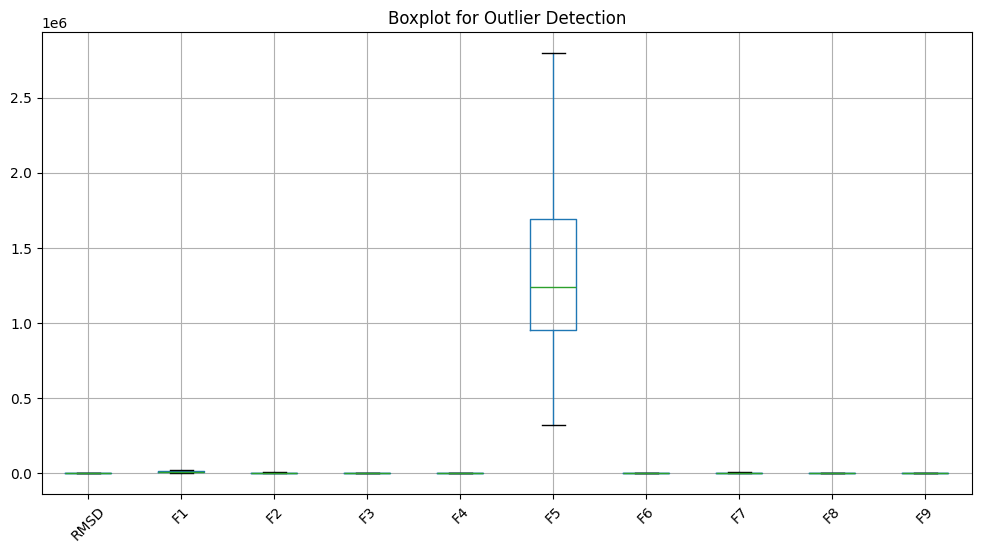

In [7]:
def count_outliers_iqr(df):
    outlier_report = {}

    numeric_cols = df.select_dtypes(include=['number']).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR


        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_report[col] = len(outliers)

    return outlier_report

print("\n--- จำนวน Outliers ในแต่ละคอลัมน์ ---")
outliers = count_outliers_iqr(df)
for col, count in outliers.items():
    print(f"{col}: {count} ค่า")


plt.figure(figsize=(12, 6))
df.boxplot()
plt.title('Boxplot for Outlier Detection')
plt.xticks(rotation=45)
plt.show()

โหลดข้อมูลหลังทำการลบแถวซ้ำ

In [19]:
df = pd.read_csv('protein_no_duplicates.csv')

ดูข้อมูลพื้นฐาน

In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44008 entries, 0 to 44007
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    44008 non-null  float64
 1   F1      44008 non-null  float64
 2   F2      44008 non-null  float64
 3   F3      44008 non-null  float64
 4   F4      44008 non-null  float64
 5   F5      44008 non-null  float64
 6   F6      44008 non-null  float64
 7   F7      44008 non-null  float64
 8   F8      44008 non-null  float64
 9   F9      44008 non-null  float64
dtypes: float64(10)
memory usage: 3.4 MB
None


ดูข้อมูล5แถวแรก

In [21]:
print(df.head())

     RMSD        F1       F2       F3        F4            F5        F6  \
0  17.284  13558.30  4305.35  0.31754  162.1730  1.872791e+06  215.3590   
1   6.021   6191.96  1623.16  0.26213   53.3894  8.034467e+05   87.2024   
2   9.275   7725.98  1726.28  0.22343   67.2887  1.075648e+06   81.7913   
3  15.851   8424.58  2368.25  0.28111   67.8325  1.210472e+06  109.4390   
4   7.962   7460.84  1736.94  0.23280   52.4123  1.021020e+06   94.5234   

        F7     F8       F9  
0  4287.87  102.0  27.0302  
1  3328.91   39.0  38.5468  
2  2981.04   29.0  38.8119  
3  3248.22   70.0  39.0651  
4  2814.42   41.0  39.9147  


ตรวจสอบค่าว่าง

In [22]:
print(df.isnull().sum())

RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      0
F9      0
dtype: int64


ตรวจสอบค่าซ้ำ

In [26]:
before = len(df)
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    print(f"พบค่าซ้ำทั้งหมด {duplicate_count} แถว กำลังดำเนินการลบ...")


    df = df.drop_duplicates().reset_index(drop=True)


    output_file = 'protein_no_duplicates.csv'
    df.to_csv(output_file, index=False)

    after = len(df)
    print(f"ลบเสร็จแล้ว!")
    print(f"จำนวนแถวเดิม: {before}")
    print(f"จำนวนแถวที่เหลือ: {after}")
    print(f"บันทึกไฟล์ใหม่ไปที่: {output_file}")
else:
    print("ไม่พบค่าซ้ำในไฟล์นี้")

ไม่พบค่าซ้ำในไฟล์นี้


ตรวจสอบoutlier ด้วยวิธีIQR


--- จำนวน Outliers ในแต่ละคอลัมน์ ---
RMSD: 0 ค่า
F1: 1104 ค่า
F2: 1189 ค่า
F3: 0 ค่า
F4: 1165 ค่า
F5: 1018 ค่า
F6: 1239 ค่า
F7: 525 ค่า
F8: 0 ค่า
F9: 137 ค่า


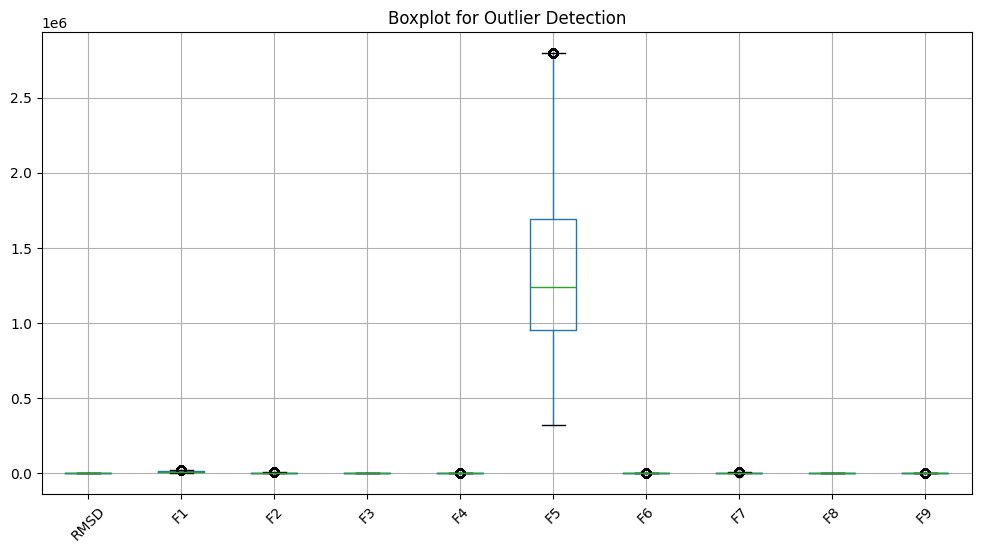

In [25]:
def count_outliers_iqr(df):
    outlier_report = {}

    numeric_cols = df.select_dtypes(include=['number']).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR


        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_report[col] = len(outliers)

    return outlier_report

print("\n--- จำนวน Outliers ในแต่ละคอลัมน์ ---")
outliers = count_outliers_iqr(df)
for col, count in outliers.items():
    print(f"{col}: {count} ค่า")


plt.figure(figsize=(12, 6))
df.boxplot()
plt.title('Boxplot for Outlier Detection')
plt.xticks(rotation=45)
plt.show()

เนื่องจากก่อนหน้านี้ทำEDAไปแล้ว แต่พบว่ายังมีค่าซ้ำหลงเหลืออยู่ จึงทำการลบหมดแล้วเป็นข้อมูลที่พร้อมใช้